In [4]:
import pandas as pd
import numpy as np
import re
import nltk # for basics
import matplotlib.pyplot as plt #visualization
from nltk.corpus import stopwords #to remove be verbs unwanted words
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud


#download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [5]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [6]:
print("Customer Reviews Dataset")
print(df.head)

Customer Reviews Dataset
<bound method NDFrame.head of                                               Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.
5      Poor quality product and terrible experience.
6                  Fast shipping and good packaging.
7        The product stopped working after two days.
8               Excellent service and great quality.
9            Late delivery and bad customer support.>


In [32]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    print('lower case',text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print('special character',text)

    #tokenization

    words=word_tokenize(text)
    print('tokenization',words)

    #remove stopwords
    words=[word for word in words if word not in stop_words]
    print('stop words',words)

    #join words again
    cleaned_text=" ".join(words)
    return ' '.join(words)

#applyig clean function

df['Cleaned_Review'] = df['Review'].apply(clean_text)
print("\n Cleaned Reviews")
print(df[['Review','Cleaned_Review']])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delive

In [43]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
    score=sia.polarity_scores(review)
    compound=score['compound']

    if compound>=0.05:
       return 'positive'
    elif compound<=-0.05:
       return 'negative'
    else:
       return 'neutral'
df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)
print("Sentiment")
print(df[['Review','Sentiment']])

Sentiment
                                              Review Sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  negative


In [44]:
all_words = " ".join(df['Cleaned_Review'])
word_list = all_words.split()

#count word frequency
word_freq = Counter(word_list)

#Display top 10 keywords
print("\nTop 10 common keywords")
print(word_freq.most_common(10))


Top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [48]:
negative_reviews = df[df['Sentiment'] == 'negative']
negative_reviews_text = " ".join(negative_reviews['Cleaned_Review'])
negative_word_list = negative_reviews_text.split()
complaint_freq = Counter(negative_word_list)
print("\nMost common complaints keywords")
print(complaint_freq.most_common(10))


Most common complaints keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


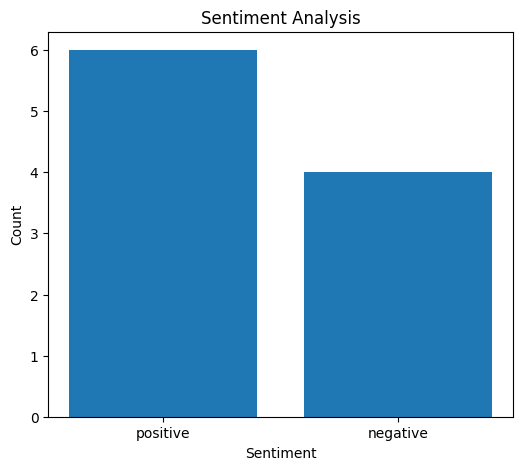

In [52]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis')
plt.show()


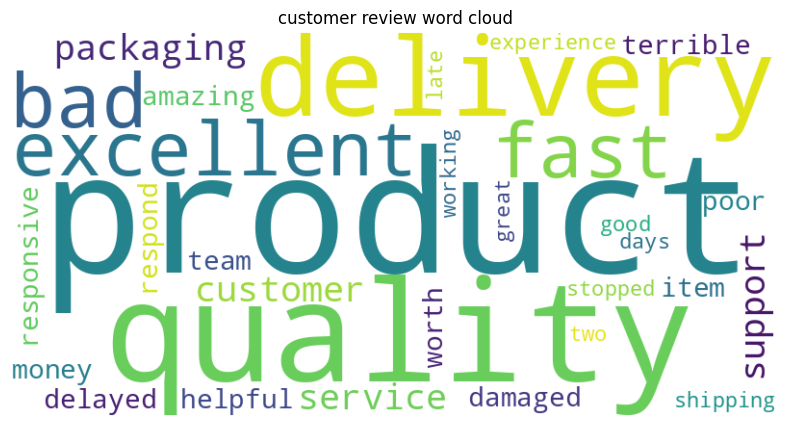

In [54]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('customer review word cloud')
plt.show()